# Classification, Credit Risk, and Default Probability

Credit risk modeling is, at its core, a classification problem: given everything known about a borrower at origination, will the loan default? This notebook builds a probability-of-default (PD) model on simulated loan-level data spanning nearly two decades (with genuine macroeconomic cycles, including recession-driven default spikes), fits and compares classification models, and validates the results the way a real credit risk function has to: not just with a single accuracy number, but with discrimination (ROC/AUC, KS), calibration (predicted vs. realized default rates), and out-of-time testing across a macro cycle the model never saw during training.


## 1. Simulating a Loan Panel with a Macro Credit Cycle

54,000 loans originated between 2006 and 2023, each with the standard predictors a credit scoring model would actually see (credit score, debt-to-income ratio, loan-to-value ratio, employment length, interest rate charged), and a **true underlying logistic default model** driving whether each loan defaults within 24 months, a known ground truth against which the fitted models below can be checked. Two recession windows (2008-09, 2020) are built into the true model as a genuine macro stress factor, elevating default risk across the *entire* portfolio in those years, not just for weak individual borrowers, exactly the systemic risk a single-loan credit score can't see coming.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

rng = np.random.default_rng(88)

n_years, n_loans_per_year = 18, 3000
n_loans = n_years * n_loans_per_year
origination_year = np.repeat(np.arange(2006, 2006 + n_years), n_loans_per_year)
origination_date = pd.to_datetime(origination_year.astype(str) + '-01-01') + \
    pd.to_timedelta(rng.integers(0, 365, n_loans), unit='D')

recession_years = {2008, 2009, 2020}
macro_stress = np.array([1.0 if y in recession_years else 0.0 for y in origination_year])
cycle = 0.3 * np.sin(2 * np.pi * (origination_year - 2006) / 9)

credit_score = np.clip(rng.normal(680, 65, n_loans), 300, 850)
dti = np.clip(rng.normal(35, 12, n_loans), 0, 80)
ltv = np.clip(rng.normal(75, 15, n_loans), 10, 105)
emp_length = np.clip(rng.exponential(6, n_loans), 0, 40)
income = np.clip(rng.lognormal(11.0, 0.5, n_loans), 15000, 500000)
loan_amount = income * rng.uniform(0.5, 4.5, n_loans)
interest_rate = np.clip(8.5 - (credit_score - 300) / 550 * 5 + rng.normal(0, 0.8, n_loans), 2, 20)

cs_std, dti_std = (credit_score - 680) / 65, (dti - 35) / 12
ltv_std, emp_std = (ltv - 75) / 15, (emp_length - 6) / 6

logit_p = (-3.6 - 1.1*cs_std + 0.55*dti_std + 0.45*ltv_std - 0.25*emp_std
           + 1.8*macro_stress + 0.9*cycle)
true_pd = 1 / (1 + np.exp(-logit_p))
default = (rng.uniform(0, 1, n_loans) < true_pd).astype(int)

df = pd.DataFrame({
    'origination_date': origination_date, 'origination_year': origination_year,
    'credit_score': credit_score, 'dti': dti, 'ltv': ltv, 'emp_length': emp_length,
    'income': income, 'loan_amount': loan_amount, 'interest_rate': interest_rate,
    'default': default,
}).sort_values('origination_date').reset_index(drop=True)

print(f"Simulated {len(df)} loans, {n_years} origination years")
print(f"Overall default rate: {df['default'].mean():.2%}")

Simulated 54000 loans, 18 origination years
Overall default rate: 7.88%


**Diagram - default rate by origination year, recession years shaded.** The macro cycle is unmistakable: default rates roughly quadruple in each recession year relative to the surrounding calm periods.

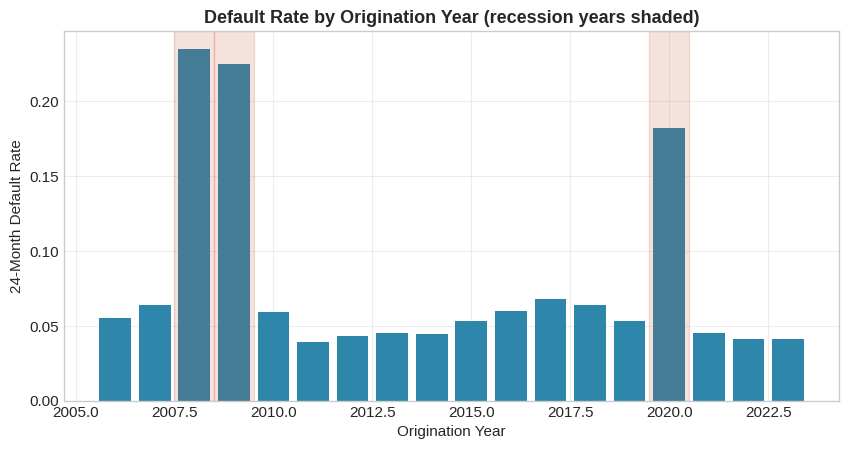

In [2]:
default_by_year = df.groupby('origination_year')['default'].mean()

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(default_by_year.index, default_by_year.values, color='#2E86AB')
for y in recession_years:
    ax.axvspan(y - 0.5, y + 0.5, color='#C73E1D', alpha=0.15)
ax.set_xlabel('Origination Year'); ax.set_ylabel('24-Month Default Rate')
ax.set_title('Default Rate by Origination Year (recession years shaded)')
plt.show()

## 2. Exploring the Data: Distributions and Joint Relationships

Before fitting any model, the raw separation in the data is worth seeing directly: how differently do defaulters and non-defaulters look on each individual feature, and in combination?

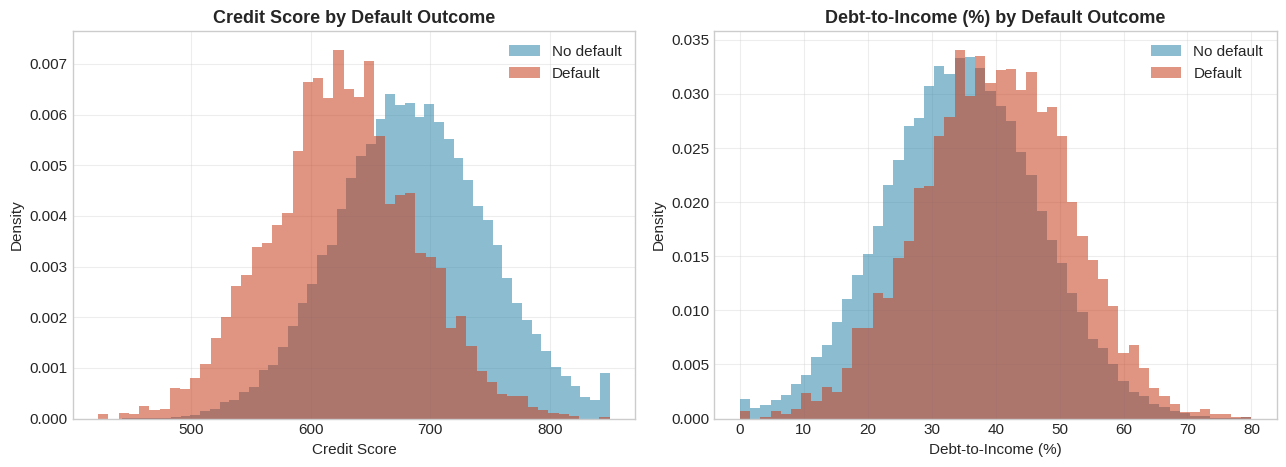

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, feat, title in [(axes[0], 'credit_score', 'Credit Score'), (axes[1], 'dti', 'Debt-to-Income (%)')]:
    ax.hist(df.loc[df['default']==0, feat], bins=50, density=True, alpha=0.55, color='#2E86AB', label='No default')
    ax.hist(df.loc[df['default']==1, feat], bins=50, density=True, alpha=0.55, color='#C73E1D', label='Default')
    ax.set_xlabel(title); ax.set_ylabel('Density')
    ax.set_title(f'{title} by Default Outcome')
    ax.legend()
plt.tight_layout()
plt.show()

**Diagram - joint scatter, credit score vs. DTI, colored by default.** Defaults cluster visibly in the low-credit-score, high-DTI corner, exactly the two risk drivers a real underwriting policy would flag, but with plenty of overlap: this is a genuinely probabilistic classification problem, not a clean rule.

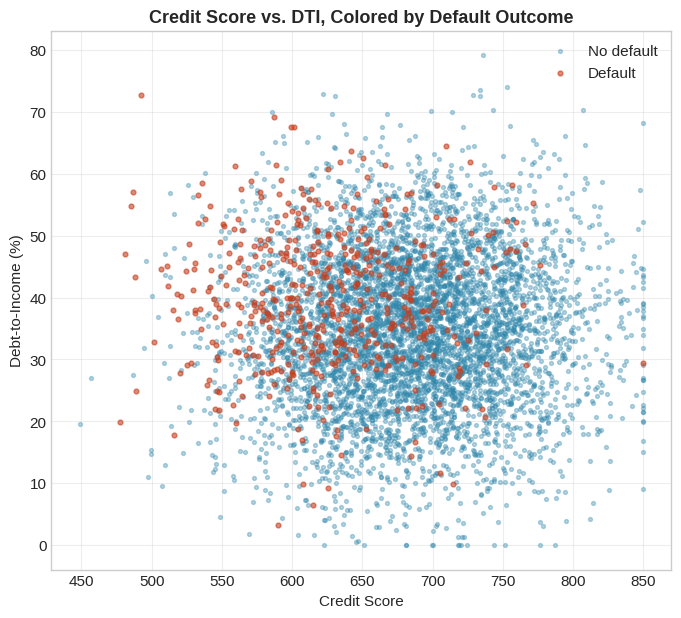

In [4]:
sample = df.sample(6000, random_state=1)  # subsample for a readable scatter
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(sample.loc[sample['default']==0, 'credit_score'], sample.loc[sample['default']==0, 'dti'],
           s=8, alpha=0.35, color='#2E86AB', label='No default')
ax.scatter(sample.loc[sample['default']==1, 'credit_score'], sample.loc[sample['default']==1, 'dti'],
           s=12, alpha=0.6, color='#C73E1D', label='Default')
ax.set_xlabel('Credit Score'); ax.set_ylabel('Debt-to-Income (%)')
ax.set_title('Credit Score vs. DTI, Colored by Default Outcome')
ax.legend()
plt.show()

## 3. Fitting Classification Models

**Logistic regression** remains the industry workhorse for credit scoring, not because it's the most flexible model available, but because its coefficients are directly interpretable (each one is a log-odds effect) and its outputs are already probabilities, exactly what a PD model needs to produce. A **gradient boosting** classifier is fit alongside it as a more flexible comparison.

Critically, this is an **out-of-time** split, not a random one: the model trains on loans originated 2006-2018 and is tested on 2019-2023, loans the model has never seen and that include an entire recession (2020) it didn't train on. This is exactly how real credit models have to be validated, since a model that only ever sees random shuffled data can look excellent in-sample while being blind to how default behavior shifts across an economic cycle.

In [5]:
features = ['credit_score', 'dti', 'ltv', 'emp_length', 'interest_rate']
train = df[df['origination_year'] <= 2018].copy()
test = df[df['origination_year'] > 2018].copy()

X_train, y_train = train[features], train['default']
X_test, y_test = test[features], test['default']

print(f"Train: {len(train)} loans (2006-2018), default rate {y_train.mean():.2%}")
print(f"Test:  {len(test)} loans (2019-2023), default rate {y_test.mean():.2%}")

logit = LogisticRegression(max_iter=1000).fit(X_train, y_train)
pred_pd_logit = logit.predict_proba(X_test)[:, 1]

print("\nLogistic regression coefficients (log-odds effects):")
for f, c in zip(features, logit.coef_[0]):
    print(f"  {f:<15}: {c:+.4f}")

gbm = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=0)
gbm.fit(X_train, y_train)
pred_pd_gbm = gbm.predict_proba(X_test)[:, 1]

print(f"\nOut-of-time AUC, logistic regression: {roc_auc_score(y_test, pred_pd_logit):.4f}")
print(f"Out-of-time AUC, gradient boosting:   {roc_auc_score(y_test, pred_pd_gbm):.4f}")

Train: 39000 loans (2006-2018), default rate 8.12%
Test:  15000 loans (2019-2023), default rate 7.27%

Logistic regression coefficients (log-odds effects):
  credit_score   : -0.0155
  dti            : +0.0413
  ltv            : +0.0265
  emp_length     : -0.0314
  interest_rate  : +0.0246

Out-of-time AUC, logistic regression: 0.7948
Out-of-time AUC, gradient boosting:   0.7917


## 4. Performance Measurement: Discrimination

**ROC/AUC** measures how well the model ranks defaulters above non-defaulters, independent of any classification threshold. The **KS statistic** (Kolmogorov-Smirnov), a credit-industry standard alongside AUC, is the maximum vertical gap between the cumulative distributions of predicted scores for defaulters and non-defaulters, the single threshold where the model best separates the two groups.

KS statistic: 0.4376  (KS > 0.40 is generally considered a strong scorecard in industry practice)


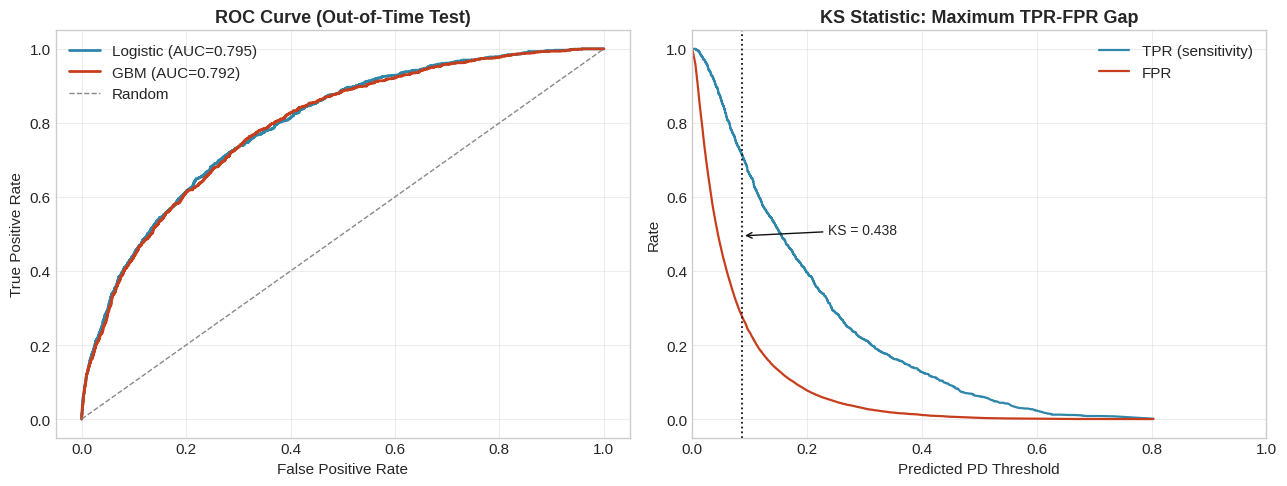

In [6]:
fpr, tpr, thresholds = roc_curve(y_test, pred_pd_logit)
ks_stat = np.max(tpr - fpr)
ks_threshold = thresholds[np.argmax(tpr - fpr)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(fpr, tpr, color='#2E86AB', linewidth=2, label=f'Logistic (AUC={roc_auc_score(y_test, pred_pd_logit):.3f})')
fpr_g, tpr_g, _ = roc_curve(y_test, pred_pd_gbm)
ax.plot(fpr_g, tpr_g, color='#C73E1D', linewidth=2, label=f'GBM (AUC={roc_auc_score(y_test, pred_pd_gbm):.3f})')
ax.plot([0, 1], [0, 1], color='#888888', linestyle='--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (Out-of-Time Test)')
ax.legend()

ax = axes[1]
ax.plot(thresholds, tpr, color='#2E86AB', linewidth=1.6, label='TPR (sensitivity)')
ax.plot(thresholds, fpr, color='#C73E1D', linewidth=1.6, label='FPR')
ax.axvline(ks_threshold, color='#111111', linestyle=':', linewidth=1.3)
ax.annotate(f'KS = {ks_stat:.3f}', xy=(ks_threshold, (tpr[np.argmax(tpr-fpr)]+fpr[np.argmax(tpr-fpr)])/2),
            xytext=(ks_threshold+0.15, 0.5), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='#111111'))
ax.set_xlim(0, 1); ax.set_xlabel('Predicted PD Threshold'); ax.set_ylabel('Rate')
ax.set_title('KS Statistic: Maximum TPR-FPR Gap')
ax.legend()

plt.tight_layout()
plt.show()

print(f"KS statistic: {ks_stat:.4f}  (KS > 0.40 is generally considered a strong scorecard in industry practice)")

## 5. Performance Measurement: Threshold-Based Metrics

A PD *score* becomes a *decision* (approve/decline, or flag for review) only once a threshold is chosen. Precision-recall trades off catching more defaulters against more false alarms; the confusion matrix at a chosen threshold makes the trade concrete.

At a 15% PD threshold: precision=0.233  recall=0.511  flagged=16.0% of the portfolio


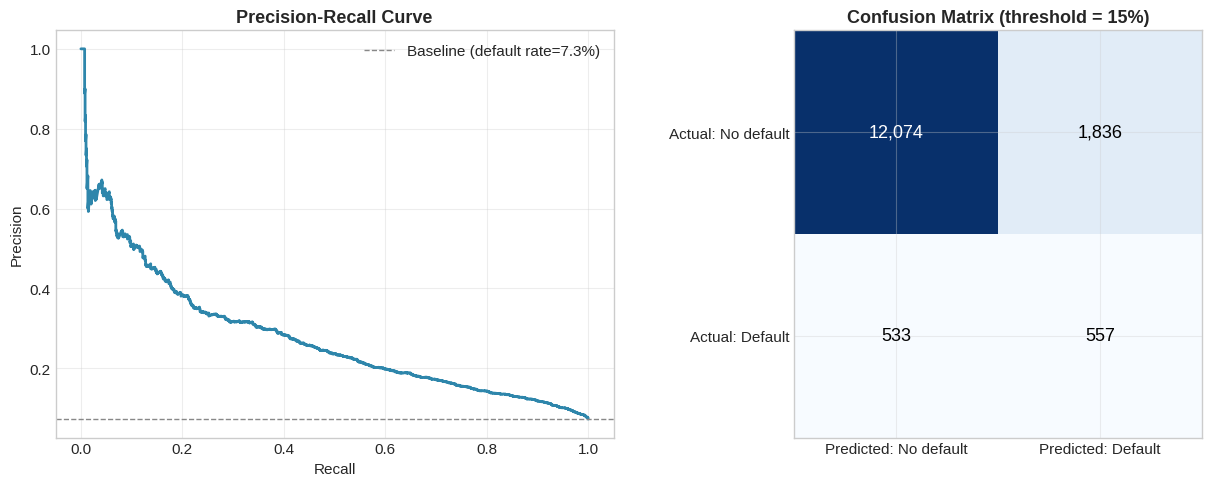

In [7]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, pred_pd_logit)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(recall, precision, color='#2E86AB', linewidth=2)
ax.axhline(y_test.mean(), color='#888888', linestyle='--', linewidth=1, label=f'Baseline (default rate={y_test.mean():.1%})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()

threshold = 0.15   # a candidate decision threshold, well above the base rate
pred_class = (pred_pd_logit >= threshold).astype(int)
cm = confusion_matrix(y_test, pred_class)

ax = axes[1]
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=13)
ax.set_xticks([0,1]); ax.set_xticklabels(['Predicted: No default', 'Predicted: Default'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Actual: No default', 'Actual: Default'])
ax.set_title(f'Confusion Matrix (threshold = {threshold:.0%})')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"At a {threshold:.0%} PD threshold: precision={tp/(tp+fp):.3f}  recall={tp/(tp+fn):.3f}  "
      f"flagged={100*(tp+fp)/len(y_test):.1f}% of the portfolio")

## 6. Calibration: Are the Predicted Probabilities Actually Right?

Discrimination (Sections 4-5) only asks whether the model *ranks* riskier loans above safer ones. **Calibration** asks a different, equally important question: when the model says "12% probability of default", do about 12% of those loans actually default? A model can have excellent AUC and still be badly calibrated, exactly what shows up here.

        mean_pred  actual_rate     n
decile                              
0          0.0066       0.0033  1500
1          0.0142       0.0127  1500
2          0.0220       0.0153  1500
3          0.0311       0.0240  1500
4          0.0423       0.0373  1500
5          0.0572       0.0600  1500
6          0.0770       0.0627  1500
7          0.1063       0.0980  1500
8          0.1591       0.1260  1500
9          0.3156       0.2873  1500


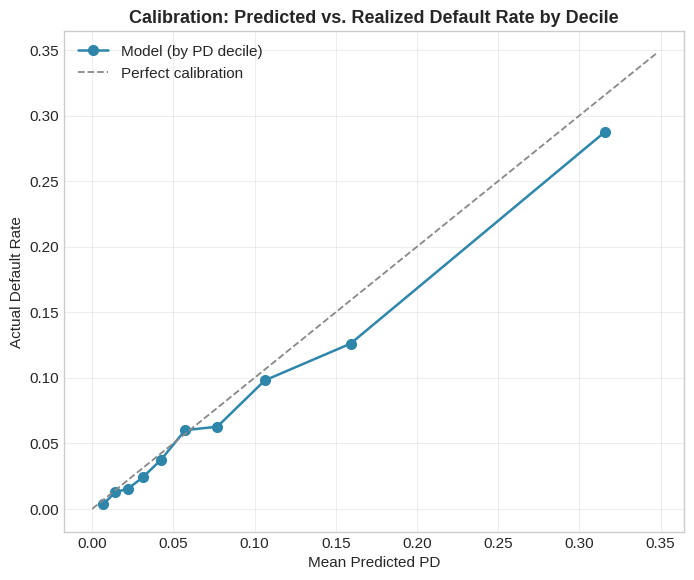

In [8]:
test = test.copy()
test['pred_pd'] = pred_pd_logit
test['decile'] = pd.qcut(test['pred_pd'], 10, labels=False, duplicates='drop')
calib = test.groupby('decile').agg(mean_pred=('pred_pd', 'mean'), actual_rate=('default', 'mean'), n=('default', 'size'))

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.plot(calib['mean_pred'], calib['actual_rate'], 'o-', color='#2E86AB', markersize=7, linewidth=1.8, label='Model (by PD decile)')
lims = [0, calib[['mean_pred','actual_rate']].values.max() * 1.1]
ax.plot(lims, lims, color='#888888', linestyle='--', linewidth=1.3, label='Perfect calibration')
ax.set_xlabel('Mean Predicted PD'); ax.set_ylabel('Actual Default Rate')
ax.set_title('Calibration: Predicted vs. Realized Default Rate by Decile')
ax.legend()
plt.show()

print(calib.round(4))

## 7. Rolling Out-of-Time Validation Across the Macro Cycle

A single train/test split hides how a model's performance actually evolves. Refitting the model on all data available *before* each year and testing on that year alone, rolled forward year by year, shows both how stable discrimination is through a cycle, and, separately, how calibration drifts.

In [9]:
rolling_results = []
for test_year in range(2010, 2024):
    tr = df[df['origination_year'] < test_year]
    te = df[df['origination_year'] == test_year]
    m = LogisticRegression(max_iter=1000).fit(tr[features], tr['default'])
    p = m.predict_proba(te[features])[:, 1]
    rolling_results.append({
        'year': test_year, 'auc': roc_auc_score(te['default'], p),
        'mean_pred_pd': p.mean(), 'actual_default_rate': te['default'].mean(),
    })
roll_df = pd.DataFrame(rolling_results).set_index('year')
print(roll_df.round(4))

         auc  mean_pred_pd  actual_default_rate
year                                           
2010  0.8351        0.1441               0.0593
2011  0.7961        0.1249               0.0390
2012  0.8018        0.1125               0.0430
2013  0.8023        0.1041               0.0453
2014  0.8162        0.0957               0.0443
2015  0.8351        0.0918               0.0530
2016  0.8309        0.0885               0.0597
2017  0.7974        0.0827               0.0677
2018  0.8109        0.0848               0.0640
2019  0.8401        0.0835               0.0530
2020  0.7934        0.0794               0.1823
2021  0.8249        0.0875               0.0453
2022  0.8139        0.0866               0.0413
2023  0.8146        0.0828               0.0413


**Diagram - rolling AUC and rolling calibration gap.** Discrimination (top) stays remarkably stable through the cycle, including the untrained-for 2020 shock, the model still ranks risky loans above safe ones correctly. Calibration (bottom) tells a different story: the model, trained on data still dominated by the 2008-09 recession, over-predicts PD through the early 2010s as that memory fades from the training window, then swings to badly under-predicting exactly in 2020, the one year an unanticipated macro shock actually hits. This gap between stable discrimination and unstable calibration is one of the most important, and most often overlooked, lessons in credit model validation.

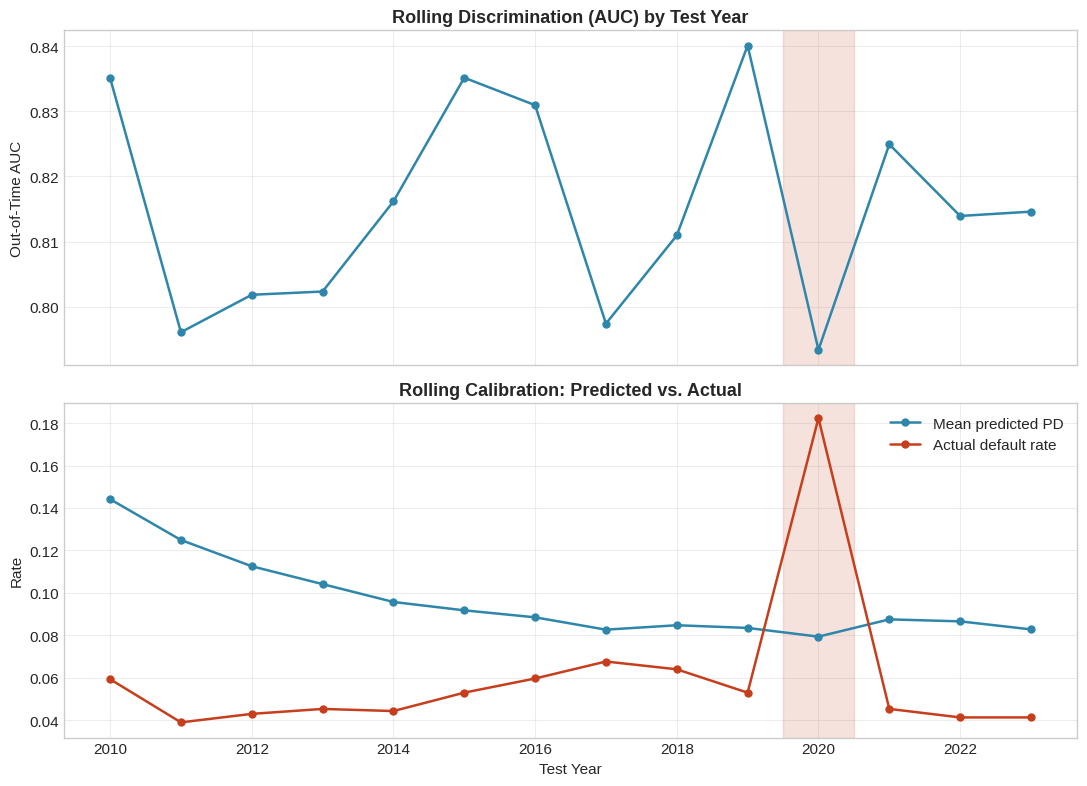

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

ax = axes[0]
ax.plot(roll_df.index, roll_df['auc'], 'o-', color='#2E86AB', linewidth=1.8, markersize=5)
ax.axvspan(2019.5, 2020.5, color='#C73E1D', alpha=0.15)
ax.set_ylabel('Out-of-Time AUC'); ax.set_title('Rolling Discrimination (AUC) by Test Year')

ax = axes[1]
ax.plot(roll_df.index, roll_df['mean_pred_pd'], 'o-', color='#2E86AB', linewidth=1.8, markersize=5, label='Mean predicted PD')
ax.plot(roll_df.index, roll_df['actual_default_rate'], 'o-', color='#C73E1D', linewidth=1.8, markersize=5, label='Actual default rate')
ax.axvspan(2019.5, 2020.5, color='#C73E1D', alpha=0.15)
ax.set_xlabel('Test Year'); ax.set_ylabel('Rate'); ax.set_title('Rolling Calibration: Predicted vs. Actual')
ax.legend()

plt.tight_layout()
plt.show()

## 8. From PD to Expected Loss

A PD model earns its keep when it feeds into **Expected Loss**, the standard building block for loss provisioning and regulatory capital:

$$\text{EL} = \text{PD} \times \text{LGD} \times \text{EAD}$$

where LGD (Loss Given Default) is the fraction of exposure actually lost if default occurs, and EAD (Exposure at Default) is the outstanding balance at the time of default. A flat 45% LGD (a common Basel-style benchmark assumption) is applied here, alongside each loan's own amount as EAD, to convert the out-of-time predicted PDs from Section 3 directly into a portfolio loss forecast, and to check that forecast against what the portfolio actually lost.

In [11]:
LGD = 0.45
test['expected_loss'] = test['pred_pd'] * LGD * test['loan_amount']
test['actual_loss'] = test['default'] * LGD * test['loan_amount']

el_by_year = test.groupby('origination_year').agg(
    predicted_EL=('expected_loss', 'sum'), actual_loss=('actual_loss', 'sum'), exposure=('loan_amount', 'sum'))
el_by_year['predicted_EL_rate'] = el_by_year['predicted_EL'] / el_by_year['exposure']
el_by_year['actual_loss_rate'] = el_by_year['actual_loss'] / el_by_year['exposure']

print(el_by_year[['predicted_EL_rate', 'actual_loss_rate']].round(4))

                  predicted_EL_rate  actual_loss_rate
origination_year                                     
2019                         0.0376            0.0217
2020                         0.0372            0.0790
2021                         0.0370            0.0199
2022                         0.0388            0.0196
2023                         0.0378            0.0185


**Diagram - predicted vs. actual portfolio loss rate.** Exactly the same story as Section 7's calibration gap, now expressed in the language a credit committee actually budgets against: dollars of expected loss, provisioned in advance, versus dollars of loss that actually showed up.

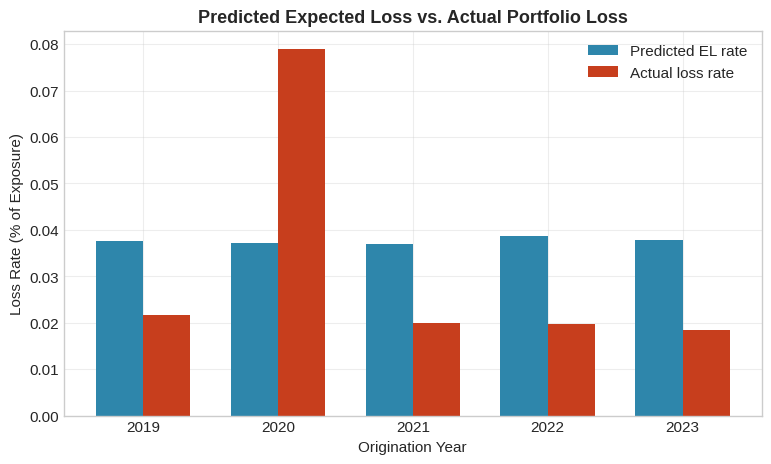

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(el_by_year))
width = 0.35
ax.bar(x_pos - width/2, el_by_year['predicted_EL_rate'], width, color='#2E86AB', label='Predicted EL rate')
ax.bar(x_pos + width/2, el_by_year['actual_loss_rate'], width, color='#C73E1D', label='Actual loss rate')
ax.set_xticks(x_pos); ax.set_xticklabels(el_by_year.index)
ax.set_xlabel('Origination Year'); ax.set_ylabel('Loss Rate (% of Exposure)')
ax.set_title('Predicted Expected Loss vs. Actual Portfolio Loss')
ax.legend()
plt.show()